In [228]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest
from sklearn.model_selection import train_test_split
from sksurv.metrics import concordance_index_censored
from sklearn.inspection import permutation_importance

### Editing the CSVs

In [ ]:
data_path = os.path.join(os.getcwd(), "data")
files = os.listdir(data_path)

In [24]:
for file in files:
    df_individual = pd.read_csv(os.path.join(data_path, file))
    try:
        df_individual["CPP"] = df_individual["MAP"] - df_individual["mean_ICP"]
    except:
        df_individual["CPP"] = df_individual["MAP"] - df_individual["ICP"]

    try:
        df_individual = df_individual.rename(columns={
        "RAP_1min": "RAP",
        "mean_ICP": "ICP",
        "meanAMP": "AMP"
        })
    except:
        pass

    df_individual.to_csv(os.path.join(data_path, file), index=False)

In [25]:
df_individual.head()

,DateTime,RAP,ICP,AMP,MAP,CPP
0,45027.539000,NaN,NaN,NaN,NaN,NaN
1,45027.539694,NaN,0.2838,0.0606,-0.2827,-0.5665
2,45027.540389,NaN,6.2230,0.3577,70.0200,63.7970
3,45027.541083,0.9990,7.7310,0.4139,73.4400,65.7090
4,45027.541777,0.9991,7.7210,0.4150,74.0800,66.3590


### Converting the Datetime Format

In [31]:
for file in files:
    df_individual = pd.read_csv(os.path.join(data_path, file))
    df_individual["DateTime"] = pd.to_datetime(df_individual["DateTime"], origin="1899-12-30", unit="D")
    
    df_individual.to_csv(os.path.join(data_path, file), index=False)

In [30]:
df_individual.head()

,DateTime,RAP,ICP,AMP,MAP,CPP
0,2019-01-04 18:19:24.389869664,NaN,NaN,NaN,NaN,NaN
1,2019-01-04 18:20:24.389874257,NaN,13.93,1.891,119.3,105.37
2,2019-01-04 18:21:24.389870685,NaN,13.31,1.842,120.0,106.69
3,2019-01-04 18:22:24.389875277,0.8784,13.87,1.924,117.7,103.83
4,2019-01-04 18:23:24.389871074,0.6063,13.90,1.854,118.8,104.90


### Adding Time-minutes Column

In [39]:
for file in files:
    df_individual = pd.read_csv(os.path.join(data_path, file))
    # converting to datetime
    df_individual["DateTime"] = pd.to_datetime(df_individual["DateTime"])
    df_individual["time_minutes"] = (df_individual["DateTime"] - df_individual["DateTime"].iloc[0]).dt.total_seconds() / 60
    
    df_individual.to_csv(os.path.join(data_path, file), index=False)

### Helper: detect first sustained RAP < 0 event

In [98]:
# Helper: detect first sustained RAP < 0 event

def first_sustained_event_time(df, threshold, consecutive_minutes):
    """
    Returns the first time_minutes at which a sustained RAP < threshold
    episode starts, or None if no sustained event exists.
    """

    rap = df["RAP"].values
    times = df["time_minutes"].values

    below = pd.Series(rap < threshold)

    run_length = 0
    start_idx = None

    for i, val in enumerate(below):
        if pd.isna(rap[i]):
            run_length = 0
            start_idx = None
            continue

        if val:
            if run_length == 0:
                start_idx = i
            run_length += 1

            if run_length >= consecutive_minutes:
                return times[start_idx]
        else:
            run_length = 0
            start_idx = None

    return None

### Helper: basic feature extraction from the first landmark hours

In [122]:
def compute_slope(time_values, signal_values):
    valid = pd.DataFrame({"t": time_values, "y": signal_values}).dropna()
    if len(valid) < 2:
        return np.nan
    return np.polyfit(valid["t"], valid["y"], 1)[0]

def extract_early_features(df_early, window_hours):
    feats = {}
    suffix = f"{window_hours}h"

    # RAP
    feats[f"rap_mean_{suffix}"] = df_early["RAP"].mean()
    feats[f"rap_std_{suffix}"] = df_early["RAP"].std()
    feats[f"rap_min_{suffix}"] = df_early["RAP"].min()
    feats[f"rap_max_{suffix}"] = df_early["RAP"].max()
    feats[f"pct_rap_gt_0_4_{suffix}"] = (df_early["RAP"] > 0.4).mean() * 100
    feats[f"pct_rap_0_to_0_4_{suffix}"] = ((df_early["RAP"] >= 0) & (df_early["RAP"] <= 0.4)).mean() * 100
    feats[f"rap_slope_{suffix}"] = compute_slope(df_early["time_minutes"], df_early["RAP"])

    # ICP
    feats[f"icp_mean_{suffix}"] = df_early["ICP"].mean()
    feats[f"icp_std_{suffix}"] = df_early["ICP"].std()
    feats[f"icp_max_{suffix}"] = df_early["ICP"].max()
    feats[f"pct_icp_gt_20_{suffix}"] = (df_early["ICP"] > 20).mean() * 100
    feats[f"icp_slope_{suffix}"] = compute_slope(df_early["time_minutes"], df_early["ICP"])

    # CPP
    feats[f"cpp_mean_{suffix}"] = df_early["CPP"].mean()
    feats[f"cpp_std_{suffix}"] = df_early["CPP"].std()
    feats[f"cpp_min_{suffix}"] = df_early["CPP"].min()
    feats[f"cpp_slope_{suffix}"] = compute_slope(df_early["time_minutes"], df_early["CPP"])

    # MAP
    feats[f"map_mean_{suffix}"] = df_early["MAP"].mean()
    feats[f"map_std_{suffix}"] = df_early["MAP"].std()
    feats[f"map_slope_{suffix}"] = compute_slope(df_early["time_minutes"], df_early["MAP"])

    # AMP
    feats[f"amp_mean_{suffix}"] = df_early["AMP"].mean()
    feats[f"amp_std_{suffix}"] = df_early["AMP"].std()
    feats[f"amp_slope_{suffix}"] = compute_slope(df_early["time_minutes"], df_early["AMP"])

    return feats

# Analysis for 3 hrs as landmark

### Main Loop

In [182]:
# Project Parameters

LANDMARK_HOURS = 3
LANDMARK_MINUTES = LANDMARK_HOURS * 60

SUSTAINED_MINUTES = 10   # RAP < 0 for 10 consecutive minutes
MIN_REQUIRED_MONITORING_MINUTES = LANDMARK_MINUTES + 1
THRESHOLD = -0.1

In [183]:
rows = []
excluded_early_event = []
excluded_short_followup = []
excluded_bad_file = []

for file in files:
    patient_id = file[:7]

    try:
        df_individual = pd.read_csv(os.path.join(data_path, file))
        # trimming starting and ending nans
        df_individual = df_individual.loc[df_individual["RAP"].first_valid_index() : df_individual["RAP"].last_valid_index()]
        
        max_time = df_individual["time_minutes"].max()

        # must at least pass the landmark
        if max_time <= LANDMARK_MINUTES:
            excluded_short_followup.append(patient_id)
            continue

        # first sustained RAP < 0 event anywhere in record
        first_event_time = first_sustained_event_time(
            df_individual,
            threshold=THRESHOLD,
            consecutive_minutes=SUSTAINED_MINUTES
        )

        # exclude if event happened during or before the LANDMARK_HOURS feature window
        if first_event_time is not None and first_event_time <= LANDMARK_MINUTES:
            excluded_early_event.append(patient_id)
            continue

        # split data
        df_early = df_individual[df_individual["time_minutes"] <= LANDMARK_MINUTES].copy()
        df_late = df_individual[df_individual["time_minutes"] > LANDMARK_MINUTES].copy()

        # need some data in both windows
        if len(df_early) == 0 or len(df_late) == 0:
            excluded_short_followup.append(patient_id)
            continue

        # features only from first LANDMARK_HOURS
        feats = extract_early_features(df_early, LANDMARK_HOURS)

        # survival outcome from AFTER LANDMARK_HOURS
        if first_event_time is not None and first_event_time > LANDMARK_MINUTES:
            event_observed = 1
            time_to_event = first_event_time - LANDMARK_MINUTES
        else:
            event_observed = 0
            time_to_event = df_individual["time_minutes"].max() - LANDMARK_MINUTES

        row = {
            "patient_id": patient_id,
            "time_to_event": time_to_event,
            "event_observed": event_observed
        }
        row.update(feats)

        rows.append(row)

    except Exception as e:
        print(f"Error in {patient_id}: {e}")
        excluded_bad_file.append(patient_id)

In [184]:
print(len(rows))
print(len(excluded_early_event))
print(len(excluded_short_followup))

73
29
7


In [185]:
survival_df = pd.DataFrame(rows)
survival_df.head()

,patient_id,time_to_event,event_observed,rap_mean_3h,rap_std_3h,rap_min_3h,rap_max_3h,pct_rap_gt_0_4_3h,pct_rap_0_to_0_4_3h,rap_slope_3h,...,cpp_mean_3h,cpp_std_3h,cpp_min_3h,cpp_slope_3h,map_mean_3h,map_std_3h,map_slope_3h,amp_mean_3h,amp_std_3h,amp_slope_3h
0,TBI_001,720.000000,1,0.691427,0.357456,-0.8324,0.9977,87.640449,3.932584,-0.001082,...,95.395557,22.060437,60.960,0.081737,108.430176,20.859914,0.031017,2.135708,0.686403,-0.008393
1,TBI_002,1538.000000,0,0.713443,0.377988,-0.9757,0.9995,84.269663,8.988764,-0.000488,...,79.439056,10.553242,58.250,-0.049834,88.383427,8.896967,-0.036226,4.887837,1.104530,0.002011
2,TBI_008,2470.561632,0,0.597290,0.437117,-0.9928,1.0000,77.401130,11.299435,0.002037,...,64.864343,2.536501,57.760,-0.012000,83.838750,2.128579,-0.031762,0.621151,0.127366,-0.000627
3,TBI_010,1658.092167,0,0.724582,0.354157,-0.5323,0.9979,85.869565,7.608696,0.004806,...,64.628141,2.141889,54.235,-0.020837,74.072391,3.186245,-0.034037,2.140457,0.283263,-0.004061
4,TBI_011,62.512164,1,0.326813,0.671496,-0.9834,0.9948,40.816327,18.367347,-0.036379,...,82.817147,4.876155,74.983,-0.349529,87.684722,3.263340,-0.173010,1.200082,0.275006,-0.005133


In [186]:
suffix = f"{LANDMARK_HOURS}h"

In [187]:
print(f"Excluded: early event before or at {suffix} =", len(excluded_early_event))
print("Excluded: too short follow-up =", len(excluded_short_followup))
print("Excluded: bad/empty files =", len(excluded_bad_file))
print("Included patients =", len(survival_df))

print(f"Later events after {suffix} =", survival_df["event_observed"].sum())
print("Censored =", (survival_df["event_observed"] == 0).sum())
print(f"Median follow-up after {suffix} (minutes) =", survival_df["time_to_event"].median())

Excluded: early event before or at 3h = 29
Excluded: too short follow-up = 7
Excluded: bad/empty files = 0
Included patients = 73
Later events after 3h = 49
Censored = 24
Median follow-up after 3h (minutes) = 1460.5134318675334


## Kaplan-Meier

### RAP group

In [188]:
kmf = KaplanMeierFitter()

col_name = f"rap_mean_{suffix}"

median_rap = survival_df[col_name].median()

survival_df["rap_group"] = np.where(
    survival_df[col_name] >= median_rap,
    f"High early RAP mean ({suffix})",
    f"Low early RAP mean ({suffix})"
)

In [189]:
survival_df.head()

,patient_id,time_to_event,event_observed,rap_mean_3h,rap_std_3h,rap_min_3h,rap_max_3h,pct_rap_gt_0_4_3h,pct_rap_0_to_0_4_3h,rap_slope_3h,...,cpp_std_3h,cpp_min_3h,cpp_slope_3h,map_mean_3h,map_std_3h,map_slope_3h,amp_mean_3h,amp_std_3h,amp_slope_3h,rap_group
0,TBI_001,720.000000,1,0.691427,0.357456,-0.8324,0.9977,87.640449,3.932584,-0.001082,...,22.060437,60.960,0.081737,108.430176,20.859914,0.031017,2.135708,0.686403,-0.008393,High early RAP mean (3h)
1,TBI_002,1538.000000,0,0.713443,0.377988,-0.9757,0.9995,84.269663,8.988764,-0.000488,...,10.553242,58.250,-0.049834,88.383427,8.896967,-0.036226,4.887837,1.104530,0.002011,High early RAP mean (3h)
2,TBI_008,2470.561632,0,0.597290,0.437117,-0.9928,1.0000,77.401130,11.299435,0.002037,...,2.536501,57.760,-0.012000,83.838750,2.128579,-0.031762,0.621151,0.127366,-0.000627,High early RAP mean (3h)
3,TBI_010,1658.092167,0,0.724582,0.354157,-0.5323,0.9979,85.869565,7.608696,0.004806,...,2.141889,54.235,-0.020837,74.072391,3.186245,-0.034037,2.140457,0.283263,-0.004061,High early RAP mean (3h)
4,TBI_011,62.512164,1,0.326813,0.671496,-0.9834,0.9948,40.816327,18.367347,-0.036379,...,4.876155,74.983,-0.349529,87.684722,3.263340,-0.173010,1.200082,0.275006,-0.005133,Low early RAP mean (3h)


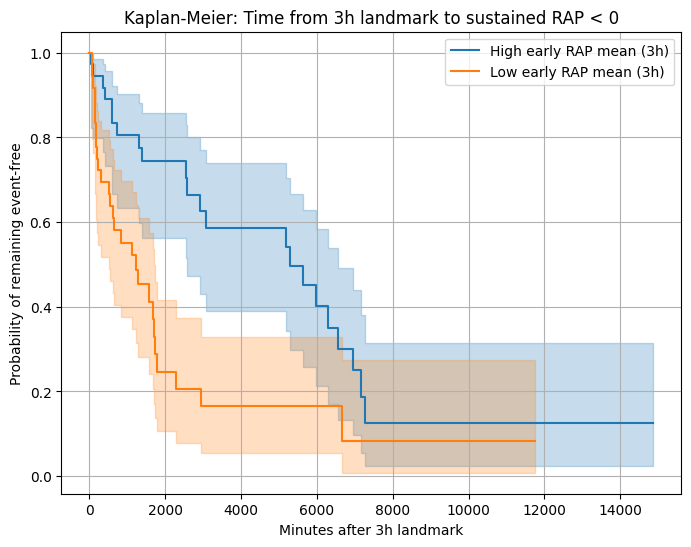

In [193]:
plt.figure(figsize=(8, 6))

for group_name, group_df in survival_df.groupby("rap_group"):
    kmf.fit(
        durations=group_df["time_to_event"],
        event_observed=group_df["event_observed"],
        label=group_name
    )
    kmf.plot_survival_function()

plt.title(f"Kaplan-Meier: Time from {suffix} landmark to sustained RAP < 0")
plt.xlabel(f"Minutes after {suffix} landmark")
plt.ylabel("Probability of remaining event-free")
plt.grid(True)
plt.savefig(f"km_curve_{suffix}_rap.jpg", dpi=300, bbox_inches="tight")  # <-- save here
plt.show()

In [191]:
g1 = survival_df[survival_df["rap_group"] == f"High early RAP mean ({suffix})"]
g2 = survival_df[survival_df["rap_group"] == f"Low early RAP mean ({suffix})"]

result = logrank_test(
    g1["time_to_event"], g2["time_to_event"],
    event_observed_A=g1["event_observed"],
    event_observed_B=g2["event_observed"]
)

print("Log-rank p-value:", result.p_value)

Log-rank p-value: 0.001640904447765404


In [192]:
kmf.median_survival_time_

np.float64(1235.0364573625834)

### ICP group

In [194]:
icp_col = f"icp_mean_{suffix}"
median_icp = survival_df[icp_col].median()

survival_df["icp_group"] = np.where(
    survival_df[icp_col] >= median_icp,
    f"High ICP ({suffix})",
    f"Low ICP ({suffix})"
)

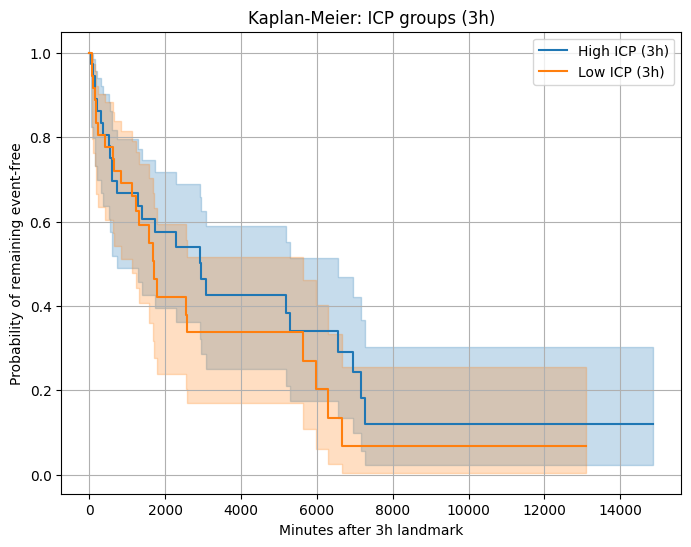

In [195]:
plt.figure(figsize=(8, 6))

for group_name, group_df in survival_df.groupby("icp_group"):
    kmf.fit(
        durations=group_df["time_to_event"],
        event_observed=group_df["event_observed"],
        label=group_name
    )
    kmf.plot_survival_function()

plt.title(f"Kaplan-Meier: ICP groups ({suffix})")
plt.xlabel(f"Minutes after {suffix} landmark")
plt.ylabel("Probability of remaining event-free")
plt.grid(True)
plt.savefig(f"km_curve_{suffix}_icp.jpg", dpi=300, bbox_inches="tight")  # <-- save here
plt.show()

In [196]:
g1 = survival_df[survival_df["icp_group"] == f"High ICP ({suffix})"]
g2 = survival_df[survival_df["icp_group"] == f"Low ICP ({suffix})"]

result = logrank_test(
    g1["time_to_event"], g2["time_to_event"],
    event_observed_A=g1["event_observed"],
    event_observed_B=g2["event_observed"]
)

print("Log-rank p-value:", result.p_value)

Log-rank p-value: 0.3530548921824682


In [197]:
kmf.median_survival_time_

np.float64(1713.0000001040669)

## Cox proportional hazards model

### For all the physiological variables set

In [206]:
cox_cols = [
    "time_to_event",
    "event_observed",
    f"rap_mean_{suffix}",
    f"icp_mean_{suffix}",
    f"cpp_mean_{suffix}",
    f"map_mean_{suffix}",
    f"amp_mean_{suffix}"
]

cox_df = survival_df[cox_cols].dropna().copy()
cox_df.head()

,time_to_event,event_observed,rap_mean_3h,icp_mean_3h,cpp_mean_3h,map_mean_3h,amp_mean_3h
0,720.000000,1,0.691427,12.851277,95.395557,108.430176,2.135708
1,1538.000000,0,0.713443,8.944371,79.439056,88.383427,4.887837
2,2470.561632,0,0.597290,19.000852,64.864343,83.838750,0.621151
3,1658.092167,0,0.724582,9.444250,64.628141,74.072391,2.140457
4,62.512164,1,0.326813,4.671382,82.817147,87.684722,1.200082


In [207]:
cph = CoxPHFitter()
cph.fit(cox_df, duration_col="time_to_event", event_col="event_observed")
cph.print_summary()
cph.summary[["coef", "exp(coef)", "p"]]

<lifelines.CoxPHFitter: fitted with 70 total observations, 23 right-censored observations>
             duration col = 'time_to_event'
                event col = 'event_observed'
      baseline estimation = breslow
   number of observations = 70
number of events observed = 47
   partial log-likelihood = -151.54
         time fit was run = 2026-04-21 04:00:47 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
rap_mean_3h -3.59      0.03      1.07           -5.69           -1.48                0.00                0.23
icp_mean_3h  0.04      1.04      0.04           -0.05            0.12                0.95                1.13
cpp_mean_3h  0.03      1.03      0.02           -0.01            0.08                0.99                1.08
map_mean_3h -0.03      0.97      0.03           -0.08            0.03                0.92                1.03
amp_mean_3h  0.03      1.03      0.15           -0.26            0.33                0.77                1.39

             cmp to     z      p  -log2(p)
covariate                                 
rap_mean_3h    0.00 -3.34 <0.005     10.20
icp_mean_3h    0.00  0.82   0.41      1.28
cpp_mean_3h    0.00  1.46   0.14      2.79
map_mean_3h    0.00 -1.02   0.31      1.71
amp_mean_3h    0.00  0.22   0.83      0.28
---
Concordance = 0.69
Partial AIC = 313.09
log-likelihood ratio test = 16.85 on 5 df
-log2(p) of ll-ratio test = 7.71

,coef,exp(coef),p
covariate,,,
rap_mean_3h,-3.586022,0.027708,0.000850
icp_mean_3h,0.035043,1.035664,0.410779
cpp_mean_3h,0.032332,1.032860,0.144589
map_mean_3h,-0.027351,0.973020,0.306227
amp_mean_3h,0.032939,1.033487,0.825577


In [208]:
cph.check_assumptions(cox_df, p_value_threshold=0.05, show_plots=False)

Proportional hazard assumption looks okay.


[]

In [201]:
survival_df.to_csv(f"patient_level_survival_dataset_{suffix}.csv", index=False)
cph.summary.to_csv(f"cox_summary_{suffix}.csv")

In [202]:
print("C-index:", cph.concordance_index_)

C-index: 0.6871095968199886


### For RAP set variables

In [209]:
cox_cols = [
    "time_to_event",
    "event_observed",
    f"rap_mean_{suffix}",
    f"rap_std_{suffix}",
    f"pct_rap_gt_0_4_{suffix}",
    f"pct_rap_0_to_0_4_{suffix}"
]

cox_df = survival_df[cox_cols].dropna().copy()
cox_df.head()

,time_to_event,event_observed,rap_mean_3h,rap_std_3h,pct_rap_gt_0_4_3h,pct_rap_0_to_0_4_3h
0,720.000000,1,0.691427,0.357456,87.640449,3.932584
1,1538.000000,0,0.713443,0.377988,84.269663,8.988764
2,2470.561632,0,0.597290,0.437117,77.401130,11.299435
3,1658.092167,0,0.724582,0.354157,85.869565,7.608696
4,62.512164,1,0.326813,0.671496,40.816327,18.367347


In [210]:
cph = CoxPHFitter()
cph.fit(cox_df, duration_col="time_to_event", event_col="event_observed")
cph.print_summary()
cph.summary[["coef", "exp(coef)", "p"]]

<lifelines.CoxPHFitter: fitted with 73 total observations, 24 right-censored observations>
             duration col = 'time_to_event'
                event col = 'event_observed'
      baseline estimation = breslow
   number of observations = 73
number of events observed = 49
   partial log-likelihood = -162.86
         time fit was run = 2026-04-21 04:01:40 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
rap_mean_3h         -2.92      0.05      1.28           -5.43           -0.41                0.00                0.66
rap_std_3h           0.39      1.47      1.65           -2.84            3.62                0.06               37.40
pct_rap_gt_0_4_3h    0.02      1.02      0.02           -0.02            0.05                0.98                1.05
pct_rap_0_to_0_4_3h  0.04      1.04      0.03           -0.01            0.10                0.99                1.10

                     cmp to     z    p  -log2(p)
covariate                                       
rap_mean_3h            0.00 -2.28 0.02      5.47
rap_std_3h             0.00  0.24 0.81      0.30
pct_rap_gt_0_4_3h      0.00  1.02 0.31      1.70
pct_rap_0_to_0_4_3h    0.00  1.61 0.11      3.21
---
Concordance = 0.67
Partial AIC = 333.73
log-likelihood ratio test = 15.49 on 4 df
-log2(p) of ll-ratio test = 8.04

,coef,exp(coef),p
covariate,,,
rap_mean_3h,-2.920853,0.053888,0.022591
rap_std_3h,0.388456,1.474702,0.813829
pct_rap_gt_0_4_3h,0.017714,1.017872,0.308398
pct_rap_0_to_0_4_3h,0.043884,1.044861,0.108057


In [211]:
cph.check_assumptions(cox_df, p_value_threshold=0.05, show_plots=False)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 73 total observations, 24 right-censored observations>
         test_name = proportional_hazard_test

---
                          test_statistic    p  -log2(p)
pct_rap_0_to_0_4_3h km              0.52 0.47      1.08
                    rank            0.87 0.35      1.51
pct_rap_gt_0_4_3h   km              6.03 0.01      6.16
                    rank            4.88 0.03      5.20
rap_mean_3h         km              4.49 0.03      4.88
                    rank            3.87 0.05      4.35
rap_std_3h          km              0.14 0.71      0.50
                    rank            0.12 0.73      0.46



1. Variable 'rap_mean_3h' failed the non-proportional test: p-value is 0.0340.

   Advice 1: the functional form of the variable 'rap_mean_3h' might be incorrect. That is, there
may be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'rap_mean_3h' using pd.cut, and then specify it in
`strata=['rap_mean_3h', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'pct_rap_gt_0_4_3h' failed the non-proportional test: p-value is 0.0140.

   Advice 1: the functional form of the variable 'pct_rap_gt_0_4_3h' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below 

[]

In [212]:
print("C-index:", cph.concordance_index_)

C-index: 0.6730175077239959


## Random Survival Forest

In [257]:
y = Surv.from_dataframe(
    event="event_observed",
    time="time_to_event",
    data=survival_df
)

## For all the physiological variables set

In [258]:
suffix = f"{LANDMARK_HOURS}h"

feature_cols = [
    f"rap_mean_{suffix}",
    f"icp_mean_{suffix}",
    f"cpp_mean_{suffix}",
    f"map_mean_{suffix}",
    f"amp_mean_{suffix}"
]

X = survival_df[feature_cols].dropna().copy()
y = y[X.index]   # align

In [259]:
rsf = RandomSurvivalForest(
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rsf

,n_estimators,200
,max_depth,None
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,bootstrap,True
,oob_score,False
,n_jobs,-1
,random_state,42


In [260]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

rsf.fit(X_train, y_train)

cindex_test = concordance_index_censored(
    y_test["event_observed"],
    y_test["time_to_event"],
    rsf.predict(X_test)
)[0]

print("Test C-index:", cindex_test)

Test C-index: 0.6129032258064516


In [261]:
result = permutation_importance(
    rsf,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

importance = pd.Series(
    result.importances_mean,
    index=feature_cols
).sort_values(ascending=False)

print(importance)

rap_mean_3h    0.040645
cpp_mean_3h    0.023548
map_mean_3h    0.016452
icp_mean_3h   -0.026452
amp_mean_3h   -0.062258
dtype: float64


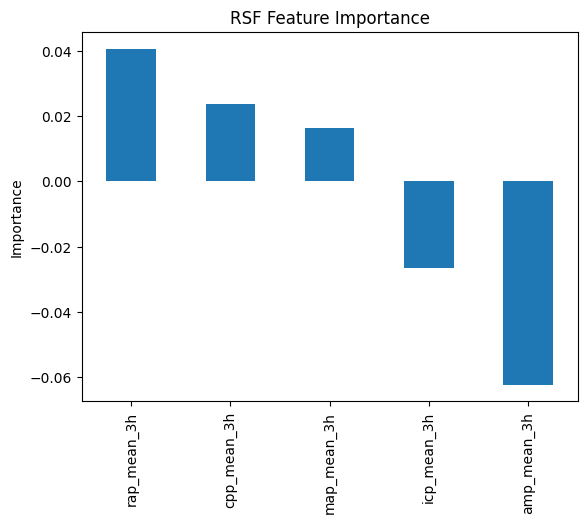

In [262]:
importance.plot(kind="bar")
plt.title("RSF Feature Importance")
plt.ylabel("Importance")
plt.savefig(f"rsf_feat_imp{suffix}_param.jpg", dpi=300, bbox_inches="tight")  # <-- save here
plt.show()

### For RAP set variables

In [265]:
y = Surv.from_dataframe(
    event="event_observed",
    time="time_to_event",
    data=survival_df
)

In [266]:
suffix = f"{LANDMARK_HOURS}h"

feature_cols = [
    f"rap_mean_{suffix}",
    f"rap_std_{suffix}",
    f"pct_rap_gt_0_4_{suffix}",
    f"pct_rap_0_to_0_4_{suffix}"
]

X = survival_df[feature_cols].dropna().copy()
y = y[X.index]   # align

In [267]:
rsf = RandomSurvivalForest(
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rsf

,n_estimators,200
,max_depth,None
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,bootstrap,True
,oob_score,False
,n_jobs,-1
,random_state,42


In [268]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

rsf.fit(X_train, y_train)

cindex_test = concordance_index_censored(
    y_test["event_observed"],
    y_test["time_to_event"],
    rsf.predict(X_test)
)[0]

print("Test C-index:", cindex_test)

Test C-index: 0.6958762886597938


In [269]:
result = permutation_importance(
    rsf,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

importance = pd.Series(
    result.importances_mean,
    index=feature_cols
).sort_values(ascending=False)

print(importance)

pct_rap_0_to_0_4_3h    0.096392
rap_mean_3h            0.067010
pct_rap_gt_0_4_3h      0.034278
rap_std_3h            -0.015464
dtype: float64


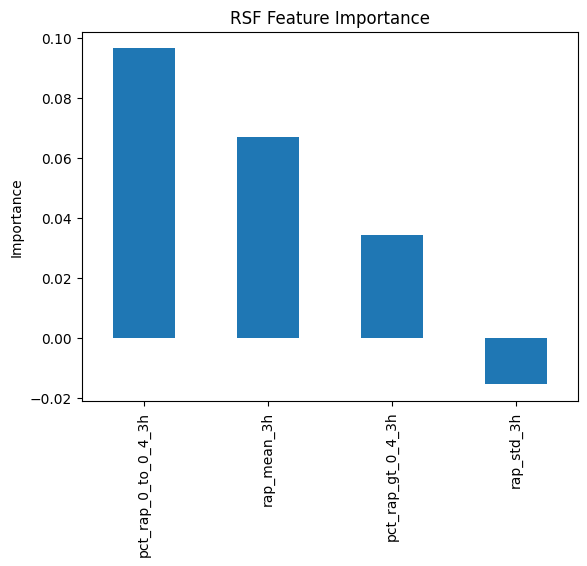

In [270]:
importance.plot(kind="bar")
plt.title("RSF Feature Importance")
plt.ylabel("Importance")
plt.savefig(f"rsf_feat_imp{suffix}_rap.jpg", dpi=300, bbox_inches="tight")  # <-- save here
plt.show()